# 03 - Baseline, candidate models, validation and final model
Code: `src/churn/modeling.py`, `src/churn/final_model.py`.

> **At a glance**
> * Out-of-time validation: tune on the Jan-Mar 2024 quarter, test on Apr-Jun 2024 (the given label), never a random split.
> * Baseline recency rule: active PR-AUC 0.514. Logistic regression: **0.828** (95% CI 0.775-0.873). LightGBM 0.823 -
>   a statistical tie (bootstrap PR-AUC difference +0.005, CI -0.019 to +0.029).
> * Stable over time: across three consecutive test quarters the logistic regression averages PR-AUC 0.824 +/- 0.019 and
>   beats every other model in each quarter.
> * Selected: logistic regression - equally accurate, best calibrated, and every score splits into exact per-member reasons.
> * Contacting the riskiest 10% of active members reaches **76%** of the quarter's churners at 73% precision.

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P

## 1. Validation design
| Step | Train on snapshots | Evaluate on | Used for |
|---|---|---|---|
| Tuning | 2023-06 + 2023-09 | 2023-12 (label Jan-Mar 2024) | thresholds, tree counts, regularisation check |
| Test | 2023-06 + 2023-09 + 2023-12 | 2024-03 (label Apr-Jun 2024, the given `CHURNED`) | all reported results |
| Production scoring | all four labelled snapshots | 2024-06-30 members (Jul-Sep 2024) | forward scores, scenarios |

* **Available at prediction time:** everything up to the cutoff month. **Not available:** anything after it,
  including the label table's last-purchase and months-observed columns.
* **Why this mimics the business:** the model is retrained on past quarters and scores the next one.
* **What could still be optimistic:** one test quarter; rebuilt training labels (~0.4% noise); the data look synthetic
  (signals are unusually clean), so live performance should be re-checked.

## 2. Baseline and candidate models on the test quarter

In [2]:
m = tab("model_comparison")
m[["population", "model", "val PR-AUC", "ROC-AUC", "PR-AUC", "PR-AUC CI low", "PR-AUC CI high", "Brier", "threshold",
   "precision", "recall", "F1", "accuracy"]].round(3)

,population,model,val PR-AUC,ROC-AUC,PR-AUC,PR-AUC CI low,PR-AUC CI high,Brier,threshold,precision,recall,F1,accuracy
0,all,rule_recency,0.926,0.971,0.955,0.944,0.965,0.061,0.344,0.984,0.852,0.914,0.945
1,active,rule_recency,0.459,0.861,0.514,0.437,0.589,0.069,0.164,0.498,0.683,0.576,0.904
2,all,logreg,0.978,0.992,0.989,0.984,0.992,0.026,0.651,0.981,0.913,0.946,0.964
3,active,logreg,0.803,0.962,0.828,0.775,0.873,0.034,0.384,0.788,0.726,0.756,0.955
4,all,logreg_balanced,0.977,0.992,0.988,0.984,0.992,0.032,0.843,0.980,0.911,0.945,0.963
5,active,logreg_balanced,0.797,0.961,0.816,0.756,0.865,0.043,0.688,0.782,0.701,0.740,0.953
6,all,random_forest,0.971,0.991,0.987,0.983,0.991,0.028,0.287,0.923,0.948,0.936,0.955
7,active,random_forest,0.734,0.955,0.817,0.764,0.863,0.038,0.257,0.658,0.774,0.711,0.940
8,all,lightgbm,0.973,0.992,0.988,0.984,0.992,0.026,0.639,0.983,0.918,0.949,0.966
9,active,lightgbm,0.776,0.960,0.823,0.769,0.872,0.034,0.271,0.719,0.780,0.749,0.950


* The **recency rule** (risk rises with months since the last purchase) is the baseline. It is already excellent
  on all eligible members (ROC-AUC 0.971) because lapsed members are easy, but weak on active members (PR-AUC 0.514).
* **Accuracy is not used to choose:** predicting "no churn" for every active member is already 90.4% accurate.
* **Class imbalance** (about 1 churner in 10 active members) is handled by choosing the decision threshold on the
  validation quarter. Class weights were tried: no ranking gain and worse calibration (higher Brier). No resampling.

In [3]:
tab("model_selection_summary")

,model,PR-AUC active (test),95% CI,ROC-AUC active,F1 active,Brier active,stability: PR-AUC over 3 quarters (mean +/- sd),complexity,interpretability,decision
0,rule_recency,0.514,0.437-0.589,0.861,0.576,0.069,0.502 +/- 0.038,none,fully transparent,baseline
1,logreg,0.828,0.775-0.873,0.962,0.756,0.034,0.824 +/- 0.019,low (36 coefficients),exact per-member contributions,SELECTED
2,logreg_balanced,0.816,0.756-0.865,0.961,0.740,0.043,not run,low,exact contributions,rejected (worse calibration)
3,random_forest,0.817,0.764-0.863,0.955,0.711,0.038,0.765 +/- 0.045,high (500 trees),needs SHAP / permutation,rejected (not better)
4,lightgbm,0.823,0.769-0.872,0.960,0.749,0.034,0.804 +/- 0.025,medium-high (boosted trees),needs SHAP,challenger (statistical tie)
5,lightgbm_balanced,0.827,0.774-0.873,0.960,0.744,0.037,not run,medium-high,needs SHAP,rejected (worse calibration)


## 3. Is the result stable over time? (rolling origin, 3 test quarters)

In [4]:
ro = tab("rolling_origin_stability")
display(ro.pivot_table(index="model", columns="test_snapshot", values="PR-AUC active").round(3))
tab("rolling_origin_summary").round(3)

test_snapshot,2023-09-30,2023-12-31,2024-03-31
model,,,
lightgbm,0.812,0.776,0.823
logreg,0.841,0.803,0.828
random_forest,0.743,0.734,0.817
rule_recency,0.532,0.459,0.514


,model,ROC-AUC active mean,ROC-AUC active std,ROC-AUC active min,ROC-AUC active max,PR-AUC active mean,PR-AUC active std,PR-AUC active min,PR-AUC active max
0,lightgbm,0.949,0.014,0.933,0.960,0.804,0.025,0.776,0.823
1,logreg,0.956,0.008,0.947,0.962,0.824,0.019,0.803,0.841
2,random_forest,0.943,0.013,0.929,0.955,0.765,0.045,0.734,0.817
3,rule_recency,0.842,0.017,0.827,0.861,0.502,0.038,0.459,0.532


Each quarter is predicted by a model trained only on the quarters before it. The logistic regression is the best
model in every quarter (PR-AUC 0.803-0.841) and the most stable; the gap to the rule baseline is large and consistent.

## 4. Hyperparameters: does the regularisation strength matter?

In [5]:
tab("lr_regularisation_sweep").round(4)

,C,val PR-AUC active,val ROC-AUC active,val PR-AUC all,used
0,0.01,0.8005,0.9463,0.9773,False
1,0.03,0.8034,0.9470,0.9776,False
2,0.10,0.8056,0.9476,0.9778,False
3,0.30,0.8034,0.9473,0.9776,True
4,1.00,0.7988,0.9468,0.9772,False
5,3.00,0.7959,0.9466,0.9771,False
6,10.00,0.7945,0.9464,0.9770,False


Checked on the validation quarter only: validation PR-AUC moves by less than 0.012 across a 1,000-fold range of C,
much less than the bootstrap uncertainty (about +/- 0.05). The pre-set C = 0.3 is kept; heavier tuning on ~1,700 active
members per quarter would mostly fit noise. LightGBM's tree count comes from early stopping on the validation quarter.

## 5. Logistic regression vs LightGBM, and a specialist model

In [6]:
import json
print(json.load(open(P.tables / "final_model_selection.json")))
tab("model_comparison_active_trained")[["model", "ROC-AUC", "PR-AUC", "F1", "Brier"]].round(3)

{'threshold_from_validation': 0.3835078541707785, 'bootstrap_active_population': {'ROC-AUC diff (LR - LGBM)': [0.0023054040038746845, -0.004718590990738678, 0.009190488389796535], 'PR-AUC diff (LR - LGBM)': [0.005455565774640086, -0.018846440154506688, 0.02907042651997247]}, 'lgbm_trees': 194}


,model,ROC-AUC,PR-AUC,F1,Brier
0,rule_recency (trained on active only),0.861,0.514,0.576,0.069
1,logreg (trained on active only),0.962,0.818,0.749,0.034
2,logreg_balanced (trained on active only),0.959,0.786,0.734,0.072
3,random_forest (trained on active only),0.953,0.800,0.701,0.038
4,lightgbm (trained on active only),0.960,0.821,0.735,0.034
5,lightgbm_balanced (trained on active only),0.959,0.826,0.752,0.045


The paired bootstrap puts the PR-AUC difference between the two models at +0.005 with a 95% interval from -0.019 to
+0.029: a tie. When two models tie, the simpler, calibrated and explainable one wins. A model trained only on active
members did not do better (PR-AUC 0.818), so one model serves both populations.

## 6. Final model on the held-out quarter

,population,n,churn_rate,ROC-AUC,PR-AUC,Brier,threshold,precision,recall,F1,accuracy,TP,FP,FN,TN
0,all eligible,2368,0.343,0.992,0.989,0.026,0.384,0.956,0.945,0.950,0.966,768,35,45,1520
1,active,1715,0.096,0.962,0.828,0.034,0.384,0.788,0.726,0.756,0.955,119,32,45,1519


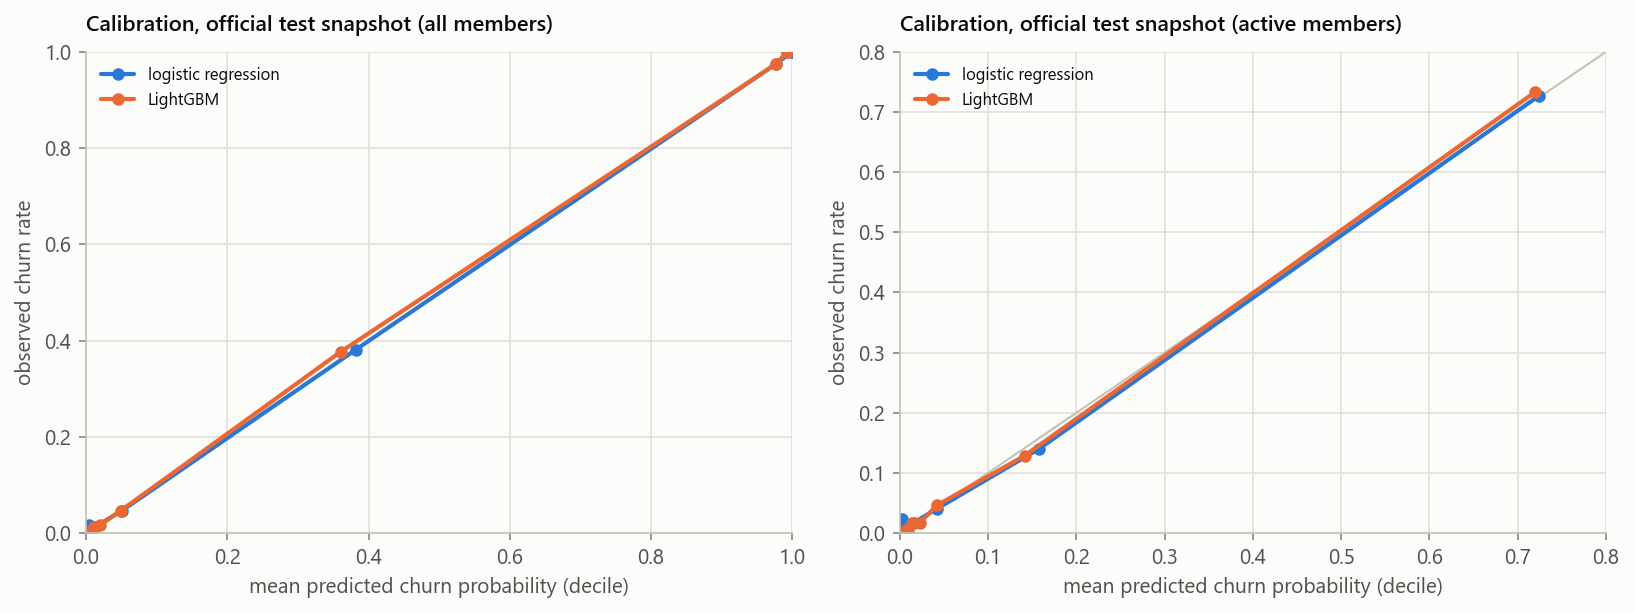

In [7]:
display(tab("final_model_test_metrics").round(3))
fig("calibration", 950)

**What does this show?** Mean predicted churn probability vs observed churn rate by decile, for all eligible and active members.

**Why is it relevant?** A retention list is only useful if a 70% score really means about 70% churn.

**What did we learn?** Both models track the diagonal; for the top decile of active members the logistic regression predicts 72.4% and 72.7% churn. Class weighting would have pushed probabilities up (Brier 0.043 vs 0.034).

**What does it imply?** Scores can be read as probabilities, which the scenario analysis relies on.

,targeted_share,members_targeted,churners_captured,share_of_churners_captured,precision_in_target,lift_vs_random
0,0.05,86,80,0.488,0.930,9.728
1,0.10,172,125,0.762,0.727,7.600
2,0.20,343,149,0.909,0.434,4.543
3,0.30,514,156,0.951,0.304,3.174
4,0.50,858,160,0.976,0.186,1.950


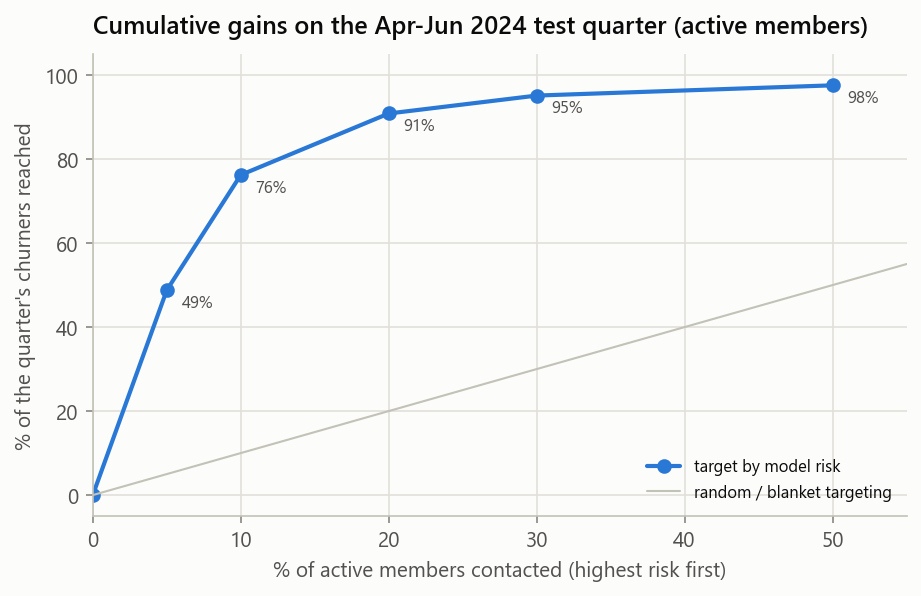

In [8]:
display(tab("gains_active").round(3))
fig("gains_active", 620)

**What does this show?** Share of the test quarter's churners reached when contacting the riskiest x% of active members.

**Why is it relevant?** The business decision is how many members to contact, not which threshold maximises F1.

**What did we learn?** The riskiest 5% contain 49% of churners, the riskiest 10% contain 76% (precision 73%, 7.6x random), the riskiest 20% contain 91%.

**What does it imply?** A monthly list of the top 10-20% of active members replaces the blanket offer.

## 7. The prediction file (deliverable)

In [9]:
p = pd.read_csv(P.predictions / "churn_predictions_apr_jun_2024.csv")
print(p.shape); p.head(8)

(2368, 10)


,customer_id,churn_probability,predicted_churn,actual_churned,population,membership_tier,city,signup_cohort,risk_band,key_drivers
0,502600,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Raleigh,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
1,500779,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Austin,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
2,500872,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Columbus,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
3,500094,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Columbus,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
4,501621,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Columbus,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
5,501630,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Columbus,2021,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
6,500815,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Nashville,2021,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...
7,500798,0.9999,1,1,lapsed (no purchase in last 3 months),Silver,Columbus,2022,high,months since last purchase = 6.0 (+2.22 logit); months since any recorded activity = 6.0 (+1.83 logit); transactions...


## 8. Experiment log (including rejected experiments)

In [10]:
tab("experiment_log")

,id,features,model,parameters,validation,result,decision
0,E01,recency + transaction-trend rule,rule (no training),-,"out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.514 (95% CI 0.437-0.589), ROC-AUC 0.861, Brier 0.069",baseline to beat
1,E02,all 36 features,logistic regression,"L2, C=0.3, no class weights","out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.828 (95% CI 0.775-0.873), ROC-AUC 0.962, Brier 0.034","SELECTED: best PR-AUC, best calibration, exact per-member reasons"
2,E03,all 36 features,logistic regression,"C=0.3, class_weight=balanced","out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.816 (95% CI 0.756-0.865), ROC-AUC 0.961, Brier 0.043","rejected: no ranking gain, worse calibration (higher Brier)"
3,E04,all 36 features,random forest,"500 trees, min_samples_leaf=20, max_features=0.4","out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.817 (95% CI 0.764-0.863), ROC-AUC 0.955, Brier 0.038","rejected: not better than LR, less interpretable"
4,E05,all 36 features,LightGBM,194 trees (early stopping on validation quarter),"out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.823 (95% CI 0.769-0.872), ROC-AUC 0.960, Brier 0.034",kept as challenger (tie with LR; used for the SHAP cross-check)
5,E06,all 36 features,LightGBM,"325 trees, scale_pos_weight","out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.827 (95% CI 0.774-0.873), ROC-AUC 0.960, Brier 0.037","rejected: no ranking gain, worse calibration"
6,E07,"all 36 features, trained on active members only",logistic regression,C=0.3,"out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)",active PR-AUC 0.818,rejected: a specialist model is not better; one model serves both populations
7,E08,all 36 features,logistic regression,"C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]",validation quarter only (2023-12 snapshot),validation PR-AUC active 0.795-0.806,flat: result does not depend on C; kept C=0.3
8,E09,all 36 features,rule / LR / RF / LightGBM,LightGBM fixed 200 trees,rolling origin: 3 consecutive test quarters,LR active PR-AUC mean 0.824 (min 0.803); LightGBM 0.804; rule 0.502,LR is the most stable and best in every quarter
9,E10,demographics only (8),logistic regression,C=0.3,"out-of-time: train 2023-06/09/12 snapshots, test 2024-03 (Apr-Jun 2024 label)","active PR-AUC 0.095, ROC-AUC 0.508",demographics alone carry no signal for active members
